In [1]:
from google.colab import files
uploaded = files.upload()

Saving student_data.csv to student_data.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [4]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())
print(df.shape)
print(df.columns)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu'

In [6]:
X = df.drop(columns=['G3'])

print(X.shape)

(395, 32)


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Processed shape:", X_processed.shape)

Processed shape: (395, 58)


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA shape: (395, 2)
Explained variance ratio: [0.13423216 0.09660874]
Total explained variance: 0.23084089779128436


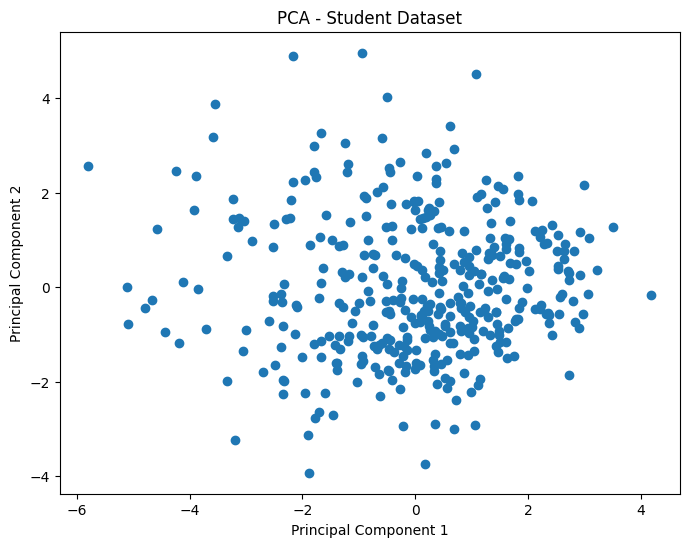

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Student Dataset")

plt.show()

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_processed)

print("t-SNE shape:", X_tsne.shape)

t-SNE shape: (395, 2)


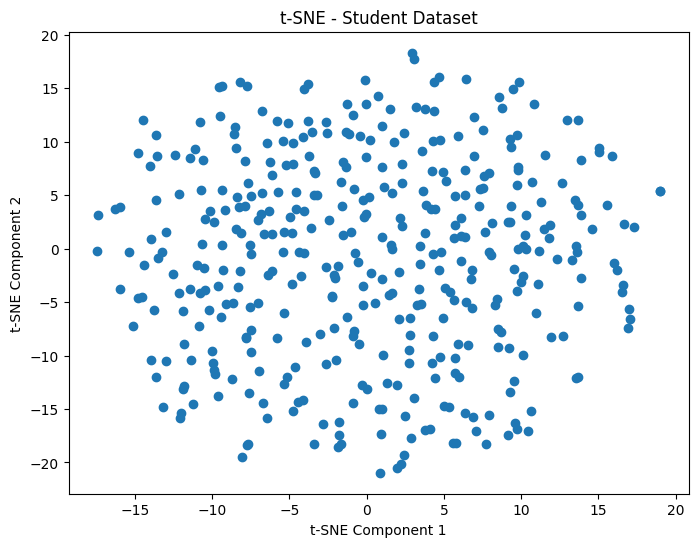

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(X_tsne[:, 0], X_tsne[:, 1])

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE - Student Dataset")

plt.show()

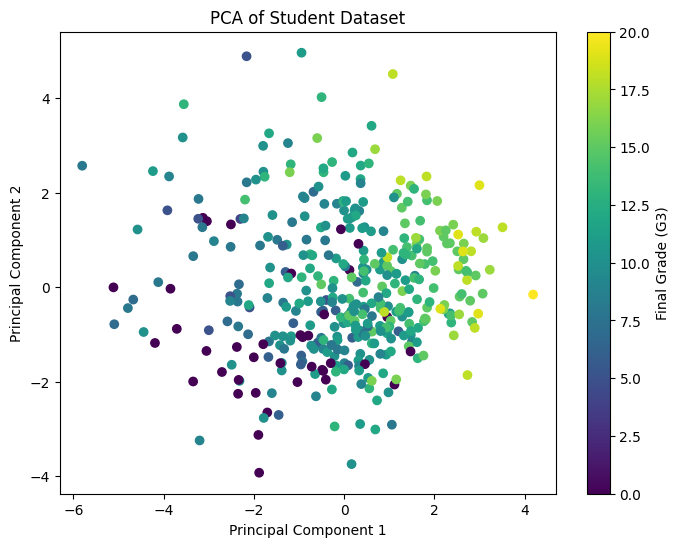

In [13]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['G3'],
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Student Dataset")

plt.colorbar(scatter, label="Final Grade (G3)")
plt.show()

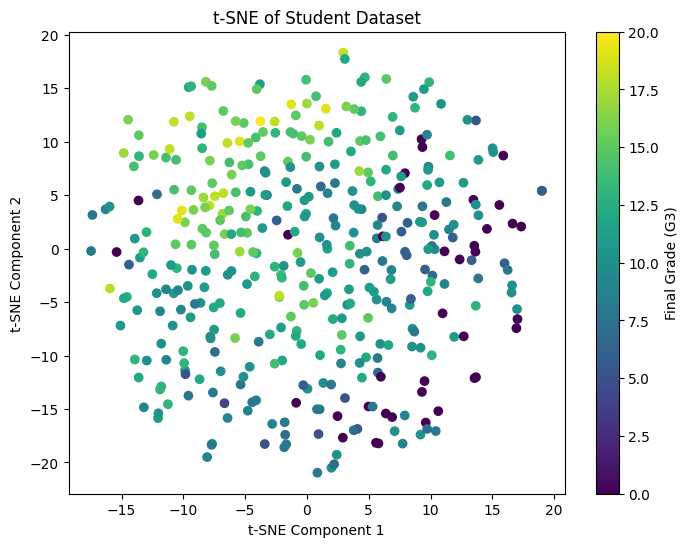

In [14]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df['G3'],
    cmap='viridis'
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE of Student Dataset")

plt.colorbar(scatter, label="Final Grade (G3)")
plt.show()

In [15]:
print("PC1 variance:", pca.explained_variance_ratio_[0])
print("PC2 variance:", pca.explained_variance_ratio_[1])

print("Total variance captured:",
      pca.explained_variance_ratio_.sum())

PC1 variance: 0.13423215887864037
PC2 variance: 0.09660873891264397
Total variance captured: 0.23084089779128436


In [16]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

tsne_df = pd.DataFrame(
    X_tsne,
    columns=['tSNE1', 'tSNE2']
)

print("PCA Reduced Data:")
print(pca_df.head())

print("\nt-SNE Reduced Data:")
print(tsne_df.head())

PCA Reduced Data:
        PC1       PC2
0 -0.466510 -0.494525
1 -1.450001 -2.701525
2 -2.490832 -1.640077
3  2.838084 -0.734830
4  0.348460 -0.915799

t-SNE Reduced Data:
       tSNE1      tSNE2
0  18.990944   5.399240
1  11.794011   1.034967
2   9.180050 -17.401957
3  -5.115133  11.747128
4   4.831663  -0.284267


In [17]:
print("Original dataset:", df.shape)
print("PCA reduced dataset:", pca_df.shape)
print("t-SNE reduced dataset:", tsne_df.shape)

Original dataset: (395, 33)
PCA reduced dataset: (395, 2)
t-SNE reduced dataset: (395, 2)
